In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import invRrs
import glob
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams.update({'font.family': 'Times New Roman',
                     'font.size': 18, 'axes.labelsize': 20,
                     })
rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

import radcalnet_oc as radoc
from invRrs import utils as u
from invRrs import solver



opj = os.path.join

## Get AERONET-OC file and export into netcdf

In [2]:
# for the sake of simplicity here all the input/ouput file path are writen by hand
native_aeronet_oc_file = 'data/AAOT_OCv3.lev20.csv'
netcdf_aeronet_oc_file = 'data/AAOT_OCv3.lev20.nc'
final_aeronet_oc_file= 'data/radcalnet_oc_input_AAOT_OCv3.lev20.nc'
full_hyper_toa_aeronetoc_file= 'data/full_hyper_radcalnet_oc_ouput_AAOT_OCv3.lev20.nc'
output_file= 'data/final_radcalnet_oc_ouput_AAOT_OCv3.lev20.nc'

In [3]:

class aeronet_driver:
    '''
    Driver extracted from another package "aeronet_visu" adaptation of https://github.com/Tristanovsk/aeronet_skycor
    '''
    
    def __init__(self,
                 file):
        self.file = file

    def read_aeronet_ocv3(self,
                          skiprows=8,
                          fwhm=15):
        ''' Read and format in pandas data.frame the standard AERONET-OC data '''

        dateparse = lambda x: dt.datetime.strptime(x, "%d:%m:%Y %H:%M:%S")
        ifile=self.file

        h1 = pd.read_csv(ifile, skiprows=skiprows - 1, nrows=1).columns[3:]
        h1 = np.insert(h1,0,'site')
        data_type = h1.str.replace('\[.*\]', '', regex=True)
        data_type = data_type.str.replace('Exact_Wave.*', 'wavelength', regex=True)
        #convert into float to order the dataframe with increasing wavelength
        h2 = h1.str.replace('.*\[', '', regex=True)
        h2 = h2.str.replace('nm\].*', '', regex=True)
        h2 = h2.str.replace('Exact_Wavelengths\(um\)_','', regex=True)
        h2 = pd.to_numeric(h2, errors='coerce') #h2.str.extract('(\d+)').astype('float')
        h2 = h2.fillna('').T
        df = pd.read_csv(ifile, skiprows=skiprows, na_values=['N/A', -999.0,-9.999999 ], parse_dates={'date': [1, 2]},
                         date_parser=dateparse, index_col=False)

        # df['site'] = site
        # df.set_index(['site', 'date'],inplace=True)
        df.set_index('date', inplace=True)

        tuples = list(zip(h1, data_type, h2))
        df.columns = pd.MultiIndex.from_tuples(tuples, names=['l0', 'l1', 'l2'])
        df = df.dropna(axis=1, how='all').dropna(axis=0, how='all')
        df.columns = pd.MultiIndex.from_tuples([(x[0], x[1], x[2]) for x in df.columns])
        df.sort_index(axis=1, level=2, inplace=True)

            
        df = df.droplevel(0, 1)
        # criteria to select scalar and spectrum values
        criteria = df.columns.get_level_values(1) == ''
        df_att = df.loc[:, criteria].droplevel(1, 1)
        df_spec = df.loc[:, ~criteria]
        
        ds = df_spec.stack().to_xarray()
        ds = xr.merge([ds, df_att.to_xarray()])
        #del df
        
        ds = ds.assign_coords({'level_1': ds.level_1.astype(float)}).rename({'level_1': "wl"})
        ds['SZA'] = ds.Solar_Zenith_Angle.mean(axis=1)
        ds['year']=ds['date.year']
        ds['season']=ds['date.season']
        ds = ds.rename_dims({'date':'time'}).rename_vars({'date':'time'})
        # remove bad character (e.g. separtor as ""/"")
        for key in ds.keys():
            if '/' in key:
                ds =ds.rename_vars({key:key.replace('/','')})

        # add Rrs calues
        ds = self.compute_Rrs(ds,fwhm=fwhm)
                
        return ds

    def compute_Rrs(self,
                    ds,
                    fwhm=15):
        '''
        Get extratrerrestrial solar irradiance and convolbve to instrument response to convert into Rrs
        :param fwhm full width at half maximum of the relative spectral response
        '''
    
        solar_irr=radoc.SolarIrradiance()

        central_wl=ds.wl     
        signal = solar_irr.tsis
        
        spectral=radoc.Spectral(central_wl,fwhm)
        F0 = spectral.convolve(signal)
        
        for param in ['Lw','Lwn','Lwn_IOP','Lwn_fQ']:
            ds['Rrs_'+param] = ds[param] / (F0 * 0.1)
        return ds

In [4]:
aeronet_oc = aeronet_driver(native_aeronet_oc_file).read_aeronet_ocv3(fwhm=15)
aeronet_oc

/tmp/ipykernel_2142659/2644300763.py:28: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(ifile, skiprows=skiprows, na_values=['N/A', -999.0,-9.999999 ], parse_dates={'date': [1, 2]},
/tmp/ipykernel_2142659/2644300763.py:28: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(ifile, skiprows=skiprows, na_values=['N/A', -999.0,-9.999999 ], parse_dates={'date': [1, 2]},
/tmp/ipykernel_2142659/2644300763.py:48: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ds = df_spec.stack().to_xarray(

<xarray.Dataset> Size: 206kB
Dimensions:                       (time: 93, wl: 11)
Coordinates:
  * time                          (time) datetime64[ns] 744B 2025-07-01T10:57...
  * wl                            (wl) float64 88B 400.0 412.0 ... 1.02e+03
Data variables: (12/45)
    Aerosol_Optical_Depth         (time, wl) float64 8kB 0.4399 ... 0.1282
    wavelength                    (time, wl) float64 8kB 0.3998 0.4123 ... 1.02
    Li_mean                       (time, wl) float64 8kB 13.03 14.63 ... 1.541
    Li_stddev                     (time, wl) float64 8kB 0.003174 ... 0.002834
    Lt_mean                       (time, wl) float64 8kB 0.742 ... 0.04688
    Lt_min_rel                    (time, wl) float64 8kB 0.6968 ... 0.03973
    ...                            ...
    year                          (time) int64 744B 2025 2025 2025 ... 2025 2025
    season                        (time) <U3 1kB 'JJA' 'JJA' ... 'JJA' 'JJA'
    Rrs_Lw                        (time, wl) float64 8kB 0.002499 ... -3.673e-06
    Rrs_Lwn                       (time, wl) float64 8kB 0.003715 ... -4.487e-06
    Rrs_Lwn_IOP                   (time, wl) float64 8kB 0.003501 ... -4.487e-06
    Rrs_Lwn_fQ                    (time, wl) float64 8kB 0.00352 ... -4.487e-06

In [5]:
# to speed up the process and dev take only one given day:
aeronet_oc = aeronet_oc.sel(time='2025-07-02')
aeronet_oc

<xarray.Dataset> Size: 22kB
Dimensions:                       (time: 10, wl: 11)
Coordinates:
  * time                          (time) datetime64[ns] 80B 2025-07-02T09:48:...
  * wl                            (wl) float64 88B 400.0 412.0 ... 1.02e+03
Data variables: (12/45)
    Aerosol_Optical_Depth         (time, wl) float64 880B 0.2742 ... 0.04547
    wavelength                    (time, wl) float64 880B 0.3998 0.4123 ... 1.02
    Li_mean                       (time, wl) float64 880B 10.46 11.55 ... 0.4877
    Li_stddev                     (time, wl) float64 880B 0.005062 ... 0.000412
    Lt_mean                       (time, wl) float64 880B 0.6491 ... 0.01545
    Lt_min_rel                    (time, wl) float64 880B 0.6092 ... 0.01298
    ...                            ...
    year                          (time) int64 80B 2025 2025 2025 ... 2025 2025
    season                        (time) <U3 120B 'JJA' 'JJA' ... 'JJA' 'JJA'
    Rrs_Lw                        (time, wl) float64 880B 0.002336 ... 3.83e-06
    Rrs_Lwn                       (time, wl) float64 880B 0.003577 ... 4.702e-06
    Rrs_Lwn_IOP                   (time, wl) float64 880B 0.003359 ... 4.702e-06
    Rrs_Lwn_fQ                    (time, wl) float64 880B 0.003382 ... 4.702e-06

## You may want to save aeronet_oc into a netcdf file

In [6]:
aeronet_oc.to_netcdf(netcdf_aeronet_oc_file)

In [7]:

# TODO speed up the process, one solution reduce degree of freedom of x by fixing S_cdom, nr for instance
def invRrs_hyperspectral_interpolation(aeronet_oc,
                                       param='Rrs_Lwn',
                                       vza=40,
                                       azi=90,
                                       wl_simu = np.linspace(350, 1200, 200)):
    # ______

    # ======================
    # IOP_star for algae data
    # =====================
    chl_models = ['Bricaud1995', 'Ciotti2002_Sf005', 'Ciotti2002_Sf01',
                  'Ciotti2002_Sf02', 'Ciotti2002_Sf03', 'Ciotti2002_Sf033',
                  'Ciotti2002_Sf05', 'Gernez_Mesodinium']
    
    aphy_star, bbphy_star = invRrs.utils.data().load_iop_phyto(chl_models[4])
    
    # ---------------------------------
    # Set forward model parameters
    # ---------------------------------
    sza = 40 # fake value to set fluorescence signal
    density = 2.65
    chl, a_cdom, S_cdom, spm_norm, fine_prop = 1, 0.05, 0.017, 0.3, 0.5
    nr, ni_ref, S_ni = 1.17, -0.003, 0.005
    xinit0 = [chl, a_cdom, S_cdom, spm_norm, fine_prop, nr, ni_ref, S_ni]
    
    # ---------------------------------
    # Set forward model parameters
    # ---------------------------------
    i = 0      

    res = []
    ressimu=[]
    resnadir=[]
    for time, aeronet_oc_ in aeronet_oc.groupby('time'):
        i += 1
        #if i > 2:
        #    break
        print(i, sep=' ', end='', flush=True)
        aeronet_oc_ = aeronet_oc_.dropna('wl').squeeze()
        
        
        wl = aeronet_oc_.wl
        Rrs_meas = aeronet_oc_[param].values 
        # remove deep blue
        # wl=wl[1:]
        # Rrs_meas=Rrs_meas[1:]
    
        sza = aeronet_oc_.SZA.values
        if sza > 80:
            continue
        aot550 = aeronet_oc_.Aerosol_Optical_Depth.interp(wl=550).values
        ws = aeronet_oc_['Wind_Speed(ms)'].values
        chl_a = aeronet_oc_["Chlorophyll-a"].values
        
        
        xinit = [chl_a, *xinit0[1:]]
    
        simu = solver.two_modes(aphy_star, bbphy_star, sza, wl_=wl_simu)
        simu.set_coef(sza, vza, azi)
        Rrs_simu = simu.forward_model(xinit, output='Rrs')
        algo = solver.two_modes(aphy_star, bbphy_star, sza, wl_=wl)
        algo.set_coef(sza, vza, azi)
    
        # perform fit
        out = algo.call_solver(Rrs_meas,
                               xinit=xinit,
                               max_nfev=30)
        if out.aborted:
            x = out.last_internal_values  # continue
        else:
            x = out.x
        
        xinit0=x
        spm_est = density * (x[3])
    
        # save outcomes
        res.append([time, *x, spm_est])
    
        # spm_est_sd = density * np.sqrt(out.covar[3,3])
        # get parameters from forward model
        Rrs_simu, a_sed, bb_sed, a_bg, bb_tot, a_tot = simu.forward_model(x, output='all')
        simu.set_coef(sza, 0, 90)
        Rrs_nadir = simu.forward_model(x, output='Rrs')
    
        ressimu.append([time,*Rrs_simu.values])
        resnadir.append([time,*Rrs_nadir.values])
   
    ressimu=np.array(ressimu)
    resnadir=np.array(resnadir)
    
    hyp_aeronet_oc = xr.Dataset(data_vars=dict(Rrs=(["time","wl"],ressimu[:,1:].astype(float)),
                                               Rrs_nadir=(["time","wl"],resnadir[:,1:].astype(float))),
                                coords=dict(
                                    time=ressimu[:,0],
                                    wl= np.linspace(350, 1100, 200)),
                                attrs=dict(description="InvRrs generated hyperspectral Rrs from multispectral AERONET-OC data"))
    hyp_aeronet_oc.Rrs.attrs = {'unit':'sr-1',
                           'long name': 'remote sensing reflectance',
                           'description': 'hyperspectral Rrs generated using InvRrs package from multispectral AERONET-OC data '+param.replace('Rrs_','') }
    hyp_aeronet_oc.Rrs_nadir.attrs = {'unit':'sr-1',
                           'long name': 'nadir remote sensing reflectance',
                           'description': 'hyperspectral Rrs generated at nadir view using InvRrs package from multispectral AERONET-OC data '+param.replace('Rrs_','') }
    # assume values out of spectral range equal to zero
    hyp_aeronet_oc = hyp_aeronet_oc.fillna(0)
    return hyp_aeronet_oc#.to_netcdf(filename)

In [8]:
hyp_aeronet_oc = invRrs_hyperspectral_interpolation(aeronet_oc)
hyp_aeronet_oc

12345678910

<xarray.Dataset> Size: 34kB
Dimensions:    (time: 10, wl: 200)
Coordinates:
  * time       (time) datetime64[ns] 80B 2025-07-02T09:48:10 ... 2025-07-02T1...
  * wl         (wl) float64 2kB 350.0 353.8 357.5 ... 1.096e+03 1.1e+03
Data variables:
    Rrs        (time, wl) float64 16kB 0.001237 0.001305 0.001377 ... 0.0 0.0
    Rrs_nadir  (time, wl) float64 16kB 0.001196 0.001262 0.00133 ... 0.0 0.0 0.0
Attributes:
    description:  InvRrs generated hyperspectral Rrs from multispectral AERON...

## Prepare final object to input radcalnet-oc processor: merge and save native and hyperspectral aeronet-oc


In [9]:
## Convert gas concentration into kg m-2
# tcwv cm into kg.m-2
tpw_cm=aeronet_oc['Total_Precipitable_Water(cm)']
aeronet_oc['tcwv']=tpw_cm*10 
aeronet_oc['tcwv'].attrs = {'unit':'kg.m-2',
                            'description': 'vertically integrated concentration of water vapor',
                            'long name':'total column of water vapor'}

# conversion DU to kg.m-2
to3_du=aeronet_oc['Total_Ozone(Du)'] 
aeronet_oc['tco3']=to3_du *2.14485e-5
aeronet_oc['tco3'].attrs = {'unit':'kg.m-2',
                            'description': 'vertically integrated concentration of ozone',
                            'long name':'total column of ozone'}

tcno2_du = aeronet_oc['Total_NO2(DU)']
aeronet_oc['tcno2']=tcno2_du*2.055482e-5
aeronet_oc['tcno2'].attrs = {'unit':'kg.m-2',
                            'description': 'vertically integrated concentration of nitrogen dioxide',
                            'long name':'total column of NO2 '}

aeronet_oc['pressure']=aeronet_oc['Pressure(hPa)']
aeronet_oc['pressure'].attrs = {'unit':'hPa',
                                'long name': 'atmospheric pressure at site level'}

aeronet_oc['sza']=aeronet_oc['SZA']
aeronet_oc['sza'].attrs['unit']='degree'
aeronet_oc['sza'].attrs['long name']='solar zenith angle'

aeronet_oc['day_of_year']=aeronet_oc['Day_of_Year']


# to make sure that AOT is available at 550nm
aeronet_oc['aot550'] = aeronet_oc['Aerosol_Optical_Depth'].interpolate_na(dim='wl').interp(wl=550)
aeronet_oc['aot550'].attrs = {'unit':'-',
                              'description': 'aerosol optical thickness measured from direct sun extinction from the AERONET CIMEL sytem',
                              'long name':'aerosol optical thickness at 550 nm'}

aeronet_oc['aot865'] = aeronet_oc['Aerosol_Optical_Depth'].interpolate_na('wl').interp(wl=865)
aeronet_oc['aot865'].attrs = {'unit':'-',
                              'description': 'aerosol optical thickness measured from direct sun extinction from the AERONET CIMEL sytem',
                              'long name':'aerosol optical thickness at 865 nm'}


# get normalizedt AOT for aerosol models retrieval
aeronet_oc['naot'] = aeronet_oc['Aerosol_Optical_Depth']/aeronet_oc['aot550']
aeronet_oc['naot'].attrs = {'unit':'-','description': 'spectral aerosol optical thickness normalized by its value at 550 nm'}
# get values for the Angstrom exponent
aeronet_oc['ang_exp'] = -(np.log(aeronet_oc['aot550']/aeronet_oc['aot865'])/np.log(550/865))# to make sure that AOT is available at 550nm
aeronet_oc['ang_exp'].attrs = {'unit':'-',
                              'description': 'angstrom exponent computed between 550 nm and 865 nm',
                              'long name':'angstrom exponent'}

aeronet_oc['Rrs_Lwn'].attrs = {'unit':'sr-1',
                              'description': 'remote sensing reflectance from AERONET-OC parameter Lwn without anisotropy correction',
                              'long name':'remote sensing reflectance from Lwn'}

aeronet_oc['Rrs_Lwn_IOP'].attrs = {'unit':'sr-1',
                              'description': 'remote sensing reflectance from AERONET-OC parameter Lwn_IOP after anisotropy correction based on the IOP method see Zibordi et al. (2021) 10.1175/JTECH-D-20-0085.1 for more information',
                              'long name':'remote sensing reflectance from Lwn_IOP'}

aeronet_oc['Rrs_Lwn_fQ'].attrs = {'unit':'sr-1',
                              'description': 'remote sensing reflectance from AERONET-OC parameter Lwn_fQ after anisotropy correction based on the f/Q method see Zibordi et al. (2021) 10.1175/JTECH-D-20-0085.1 for more information',
                              'long name':'remote sensing reflectance from Lwn_fQ'}



aeronet_oc_ = aeronet_oc[['tcwv', 'tco3', 'tcno2', 'pressure', 'sza', 'day_of_year', 'aot550', 'aot865', 'ang_exp','naot', 'Rrs_Lwn', 'Rrs_Lwn_IOP', 'Rrs_Lwn_fQ']]
aeronet_oc_ = aeronet_oc_.rename({"wl":"wl_aeronet"})

hyp_aeronet_oc.Rrs.attrs = {'unit':'sr-1',
                           'long name': 'remoate sensing reflectance',
                           'description': 'hyperspectral Rrs generated be the InvRrs package from multispectral AERONET-OC data' }

final_aeronet_oc = xr.merge([aeronet_oc_,hyp_aeronet_oc])
final_aeronet_oc


<xarray.Dataset> Size: 38kB
Dimensions:      (time: 10, wl_aeronet: 11, wl: 200)
Coordinates:
  * time         (time) datetime64[ns] 80B 2025-07-02T09:48:10 ... 2025-07-02...
  * wl_aeronet   (wl_aeronet) float64 88B 400.0 412.0 443.0 ... 865.0 1.02e+03
  * wl           (wl) float64 2kB 350.0 353.8 357.5 ... 1.096e+03 1.1e+03
Data variables: (12/15)
    tcwv         (time) float64 80B 34.32 34.75 34.73 ... 33.65 33.53 33.36
    tco3         (time) float64 80B 0.007223 0.007222 ... 0.007221 0.007221
    tcno2        (time) float64 80B 5.416e-06 5.416e-06 ... 5.414e-06 5.414e-06
    pressure     (time) float64 80B 1.016e+03 1.016e+03 ... 1.015e+03 1.015e+03
    sza          (time) float64 80B 28.17 24.07 23.72 ... 29.53 30.17 30.82
    day_of_year  (time) int64 80B 183 183 183 183 183 183 183 183 183 183
    ...           ...
    naot         (time, wl_aeronet) float64 880B 1.812 1.729 ... 0.4419 0.3323
    Rrs_Lwn      (time, wl_aeronet) float64 880B 0.003577 0.003441 ... 4.702e-06
    Rrs_Lwn_IOP  (time, wl_aeronet) float64 880B 0.003359 0.003225 ... 4.702e-06
    Rrs_Lwn_fQ   (time, wl_aeronet) float64 880B 0.003382 0.003239 ... 4.702e-06
    Rrs          (time, wl) float64 16kB 0.001237 0.001305 0.001377 ... 0.0 0.0
    Rrs_nadir    (time, wl) float64 16kB 0.001196 0.001262 0.00133 ... 0.0 0.0

In [10]:
# save netcdf
final_aeronet_oc.to_netcdf(final_aeronet_oc_file)

## Now process BOA to TOA with fine hyperspectral resolution of monochromatic bands

The version I use:
```
start_date='2020-01-01'
end_date='2024-12-31'
vzas = [0,10,20,30,40]
azis = [0,45,90,135,180]
vza = xr.DataArray(vzas,coords={'vza':vzas},dims='vza')

dssub = xtemp.sel(time=slice(start_date,end_date))
for year, ds_ in dssub.groupby('time.year'):
    for month, ds__ in ds_.groupby('time.month'):        
        ds__['naot']=ds__.naot.dropna('wl_aeronet',how='all').squeeze()
        if len(ds__.time)<2:
            print(year, month)
            continue
        filename = opj(odir,'full_spectral',site, site + '_radcalnet-oc_' + level + '_' + f'{year}_{month:02}'+'_full_spectral.nc')
        
        if os.path.exists(filename):
            continue
        print(filename)
        odir_ = os.path.dirname(filename)
        if not os.path.exists(odir_):
            os.makedirs(odir_)
            
        # need to have both aerosol and Rrs data available:
        naot = ds__.naot.dropna('wl_aeronet',how='all').dropna('time',how='all')
        ds__ = ds__.sel(time=naot.time)
        if len(ds__.time)<2:
            continue
        radoc_process = radoc.Process(ds__,vza=vza,azi=azis)    
        aero_process = radoc.Aerosol(naot,radoc_process.lut.naot_lut)
        aero_process.process()
        model =aero_process.model_db
        ds__ = xr.merge([ds__,model])
        radoc_process.execute(aerosol_combination=model.aerosol_combination)
        
        radoc_process.radcalnet_db.squeeze().to_netcdf(filename)
```

In [11]:
vzas = [0,40] #[0,10,20,30,40]
azis = [0] #[0,45,90,135,180]
vza = xr.DataArray(vzas,coords={'vza':vzas},dims='vza')

ds = final_aeronet_oc       
ds['naot']=ds.naot.dropna('wl_aeronet',how='all').squeeze()
    
# need to have both aerosol and Rrs data available:
naot = ds.naot.dropna('wl_aeronet',how='all').dropna('time',how='all')
ds = ds.sel(time=naot.time)

radoc_process = radoc.Process(ds,vza=vza,azi=azis)    
aero_process = radoc.Aerosol(naot,radoc_process.lut.naot_lut)
aero_process.process()
model =aero_process.model_db
ds = xr.merge([ds,model])
radoc_process.execute(aerosol_combination=model.aerosol_combination)

INFO:root:get LUT object
INFO:root:loading look-up tables
INFO:root:get auxiliary data
INFO:root:loading look-up tables
INFO:root:get solar irradiance
INFO:root:get gaseous transmittance object
INFO:root:set input parameters
INFO:root:LUT preparation


In [12]:
radoc_process.radcalnet_db

<xarray.Dataset> Size: 12MB
Dimensions:              (time: 10, wl: 21532, vza: 2, model: 6)
Coordinates:
  * time                 (time) datetime64[ns] 80B 2025-07-02T09:48:10 ... 20...
  * wl                   (wl) float64 172kB 350.1 350.3 ... 2.499e+03 2.5e+03
    aot_ref              (time) float64 80B 0.1513 0.151 0.1508 ... 0.138 0.1368
  * vza                  (vza) int64 16B 0 40
  * model                (model) <U9 216B 'ARCT_rh70' 'COAV_rh70' ... 'WASO_rh0'
    sza                  (time) float64 80B 28.17 24.07 23.72 ... 30.17 30.82
Data variables: (12/14)
    Ed                   (time, wl) float64 2MB 710.6 672.4 ... 0.00208 0.4296
    Ratm                 (time, wl, vza) float64 3MB 0.2565 0.2383 ... 4.163e-08
    Rrs                  (time, wl) float64 2MB 0.001239 0.001243 ... 0.0 0.0
    E0                   (time, wl) float64 2MB 1.002e+03 947.3 ... 42.43 42.43
    Rtoa                 (time, wl, vza) float64 3MB 0.2585 0.2401 ... 4.163e-08
    tcwv                 (time) float64 80B 34.32 34.75 34.73 ... 33.53 33.36
    ...                   ...
    pressure             (time) float64 80B 1.016e+03 1.016e+03 ... 1.015e+03
    aot550               (time) float64 80B 0.1513 0.151 0.1508 ... 0.138 0.1368
    aot865               (time) float64 80B 0.06665 0.06682 ... 0.06076 0.06047
    ang_exp              (time) float64 80B 1.81 1.8 1.8 ... 1.815 1.811 1.804
    aerosol_combination  (time, model) float64 480B 0.0 0.0 ... 0.0 1.0
    D2                   (time) float64 80B 0.9666 0.9666 ... 0.9666 0.9666

In [13]:
# save into netcdf
radoc_process.radcalnet_db.to_netcdf(full_hyper_toa_aeronetoc_file)


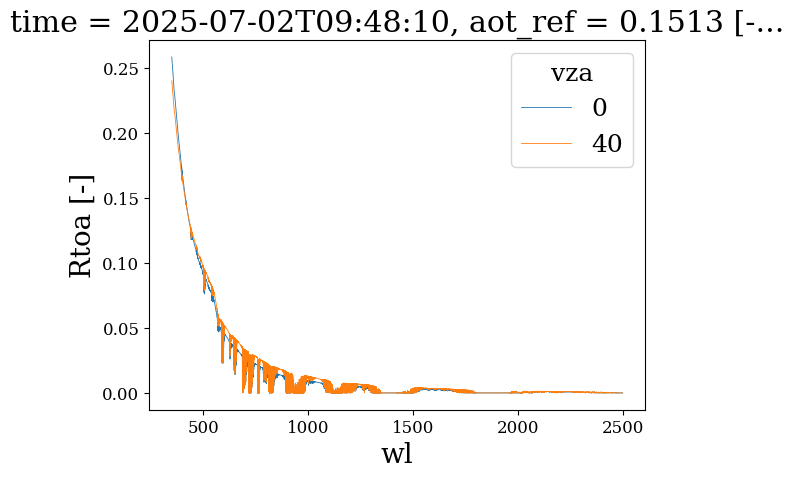

In [14]:
radoc_process.radcalnet_db.Rtoa.isel(time=0).plot(hue='vza',lw=0.6)
plt.show()

## Final step convolve with fwhm 10nm and spectral increment of 10 nm

The code I use:
```
fwhm=10
central_wl = np.arange(350,2500,10)
spectral=radoc.Spectral(central_wl,fwhm)

start_date='2017-01-01'
end_date='2024-10-31'
radcalnet_db_sub = radcalnet_db_full.sel(time=slice(start_date,end_date))
for year, ds_ in radcalnet_db_sub.groupby('time.year'):
    for month, ds__ in ds_.groupby('time.month'):        
       
        filename = opj(odir,'radcalnet',site, site + '_radcalnet-oc_' + level + '_' + f'{year}_{month:02}'+'_inc10nm_res10nm.nc')
        if os.path.exists(filename):
            continue
        odir_ = os.path.dirname(filename)
        if not os.path.exists(odir_):
            os.makedirs(odir_)
            
        radcalnet_db_int = []
        for var_name, values in ds__.items():
            print(var_name)
            if 'wl' in values.dims:
                if 'Rrs' in var_name:
                    radcalnet_db_int.append(values.interp(wl=central_wl))
                else:
                    radcalnet_db_int.append(spectral.convolve2(values,expon=3))
            else:
                radcalnet_db_int.append(values)
        radcalnet_db_int = xr.merge(radcalnet_db_int)
        radcalnet_db_int.to_netcdf(filename)
```

In [15]:
# Warning: not implemented yet for multiangular, please get only one vza and one azi values
radcalnet_db = xr.open_dataset(full_hyper_toa_aeronetoc_file).isel(vza=0).squeeze()

fwhm=10
central_wl = np.arange(350,2500,10)
spectral=radoc.Spectral(central_wl,fwhm)


            
radcalnet_db_int = []
for var_name, values in radcalnet_db.items():
    print(var_name)
    if 'wl' in values.dims:
        if 'Rrs' in var_name:
            radcalnet_db_int.append(values.interp(wl=central_wl))
        else:
            radcalnet_db_int.append(spectral.convolve2(values,expon=3))
    else:
        radcalnet_db_int.append(values)
radcalnet_db_int = xr.merge(radcalnet_db_int)

        

Ed
Ratm
Rrs
E0
Rtoa
tcwv
tco3
tcno2
pressure
aot550
aot865
ang_exp
aerosol_combination
D2


In [16]:
radcalnet_db_int

<xarray.Dataset> Size: 55kB
Dimensions:              (time: 10, wl: 215, model: 6)
Coordinates:
  * wl                   (wl) int64 2kB 350 360 370 380 ... 2460 2470 2480 2490
  * time                 (time) datetime64[ns] 80B 2025-07-02T09:48:10 ... 20...
    aot_ref              (time) float64 80B 0.1513 0.151 0.1508 ... 0.138 0.1368
    vza                  int64 8B 0
    sza                  (time) float64 80B 28.17 24.07 23.72 ... 30.17 30.82
  * model                (model) <U9 216B 'ARCT_rh70' 'COAV_rh70' ... 'WASO_rh0'
Data variables: (12/14)
    Ed                   (time, wl) float32 9kB 634.8 614.1 ... 3.796 0.2529
    Ratm                 (time, wl) float32 9kB 0.2504 0.2343 ... 2.586e-07
    Rrs                  (time, wl) float64 17kB nan 0.001425 ... 0.0 0.0
    E0                   (time, wl) float32 9kB 887.4 843.2 ... 42.95 42.42
    Rtoa                 (time, wl) float32 9kB 0.2526 0.2367 ... 2.586e-07
    tcwv                 (time) float64 80B ...
    ...                   ...
    pressure             (time) float64 80B ...
    aot550               (time) float64 80B ...
    aot865               (time) float64 80B ...
    ang_exp              (time) float64 80B ...
    aerosol_combination  (time, model) float64 480B ...
    D2                   (time) float64 80B ...
Attributes:
    unit:         mW m-2 nm-1
    description:  Plane solar irradiance at bottom-of-atmosphere

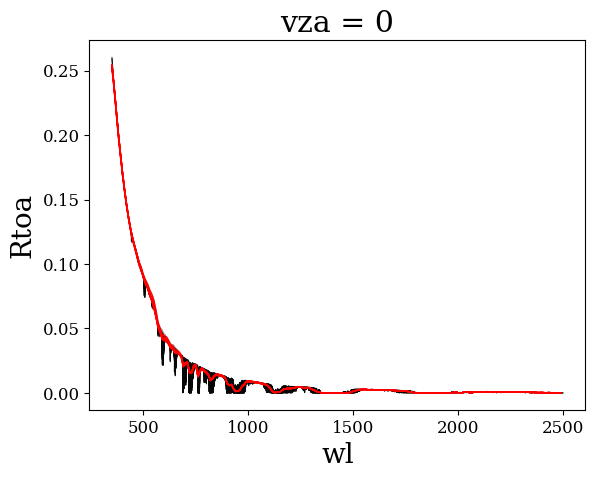

In [17]:
radcalnet_db.Rtoa.plot(hue='time',c='k',alpha=0.3,lw=0.6,add_legend=False)
radcalnet_db_int.Rtoa.plot(hue='time',c='r',lw=1,add_legend=False)
plt.show()

## Final export

In [18]:
radcalnet_db_int.to_netcdf(output_file)